# Customer Segmentation & Churn Pattern Analytics in European Banking

## Business Problem

Customer churn is one of the most significant challenges in retail banking. Retaining existing customers is considerably more cost-effective than acquiring new ones. This project analyzes customer demographics, financial characteristics, and engagement patterns to identify segments with higher churn risk.

The objective is to uncover actionable insights that support customer retention strategies through data-driven analytics.

---

**Domain:** Banking Analytics

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Author:** Tirth Maheshwari

In [1]:
# Lets start with importing our required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [2]:
# Now we can load our dataset as a panda's DataFrame

df = pd.read_csv("../data/European_Bank.csv")
data = df.copy()
data.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Dataset Overview

The dataset contains customer-level information from a European retail bank.

Each row represents one customer and includes demographic, financial, and account-related information.

The target variable is:

#### **Exited**

- 0 → Customer stayed
- 1 → Customer left (Churned)

# Now we can start with initial exploration of our data set

In [3]:
# Shape
data.shape

(10000, 14)

In [4]:
# Columns
data.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [5]:
# Data Types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [7]:
# First few rows
data.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# Last few rows
data.tail()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,2025,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [9]:
# Missing Values
print(data.isnull().sum())

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
                  ..
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
Length: 14, dtype: int64


In [10]:
# Duplicate Rows
print("Number of duplicate rows = ", data.duplicated().sum())

Number of duplicate rows =  0


# Now we can start to clean our data set

In [11]:
data["Year"].value_counts()

Year
2025    10000
Name: count, dtype: int64

In [12]:
# Removing Unnecessary Columns

data.drop(columns="Surname", inplace=True) 
data.drop(columns="CustomerId", inplace=True)
data.drop(columns="Year", inplace=True)

In [15]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Validating the Remaining Data

In [16]:
# Checking Binary Columns

binary_cols = ["HasCrCard", "IsActiveMember", "Exited"]

for col in binary_cols:
    print(f"\n{col}")
    print(data[col].value_counts())


HasCrCard
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

IsActiveMember
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

Exited
Exited
0    7963
1    2037
Name: count, dtype: int64


In [17]:
# Checking Categorical Values

print("Gender:")
print(data["Gender"].unique())

print("\nGeography:")
print(data["Geography"].unique())

Gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Geography:
<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str


In [18]:
# Checking Numerical Ranges
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


## Data Cleaning Observations

After performing the data cleaning process, the following observations were made:

- The dataset contains **10,000 customer records** with no missing values.
- No duplicate records were found, ensuring data uniqueness.
- The columns **Surname**, **CustomerId**, and **Year** were removed as they do not contribute to customer churn analysis.
- Binary variables (`HasCrCard`, `IsActiveMember`, and `Exited`) were validated and confirmed to contain only valid values (0 and 1).
- Categorical variables (`Gender` and `Geography`) were checked for consistency and contained no incorrect or unexpected categories.
- Numerical variables such as **Credit Score**, **Age**, **Balance**, **Tenure**, and **Estimated Salary** were inspected and found to be within realistic ranges.
- The dataset is clean, consistent, and ready for feature engineering and exploratory data analysis.

#### Conclusion

The data cleaning process confirmed that the dataset is of high quality, requiring only the removal of non-analytical columns. With no missing values, duplicate records, or inconsistent data, the dataset is well-prepared for customer segmentation and churn pattern analysis.

# Feature Engineering

## Objective

Feature engineering involves transforming existing variables into meaningful customer segments that simplify analysis and improve business insights.

In this project, new segmentation variables are created based on:

- Age
- Credit Score
- Account Balance
- Customer Tenure

These engineered features will be used throughout the exploratory data analysis (EDA) to identify customer groups with different churn behaviors.

## Creating Age Groups
#### Instead of comparing 75 different ages, we now compare only 4 customer groups.
Age	Group

| Age   | Group      |
| ----- | ---------- |
| <30   | Young      |
| 30–45 | Adult      |
| 46–60 | Middle Age |
| 60+   | Senior     |


In [20]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Young", "Adult", "Middle Age", "Senior"]
)

data["AgeGroup"].value_counts()

AgeGroup
Adult         5921
Young         1968
Middle Age    1647
Senior         464
Name: count, dtype: int64

## Creating Credit Score Bands
#### Banks often classify customers based on credit score.
| Credit Score | Band   |
| ------------ | ------ |
| 350–579      | Low    |
| 580–699      | Medium |
| 700–850      | High   |


In [21]:
data["CreditScoreBand"] = pd.cut(
    data["CreditScore"],
    bins=[349, 579, 699, 850],
    labels=["Low", "Medium", "High"]
)

data["CreditScoreBand"].value_counts()

CreditScoreBand
Medium    4490
High      3148
Low       2362
Name: count, dtype: int64

## Creating Balance Segments

The project specifies:

- Zero Balance
- Low Balance
- High Balance

We'll use the median of all non-zero balances as the threshold. Using the median splits non-zero balances into two balanced groups and avoids arbitrary cutoffs.

In [22]:
median_balance = data.loc[data["Balance"] > 0, "Balance"].median()

print("Median Balance:", median_balance)

Median Balance: 119839.69


In [23]:
data["BalanceSegment"] = data["Balance"].apply(
    lambda x: "Zero Balance"
    if x == 0
    else "Low Balance"
    if x <= median_balance
    else "High Balance"
)

data["BalanceSegment"].value_counts()

BalanceSegment
Zero Balance    3617
Low Balance     3192
High Balance    3191
Name: count, dtype: int64

## Create Tenure Groups

The project asks us to group customers by how long they have been with the bank.
| Tenure (Years) | Group     |
| -------------- | --------- |
| 0–3            | New       |
| 4–7            | Mid-term  |
| 8–10           | Long-term |


In [24]:
data["TenureGroup"] = pd.cut(
    data["Tenure"],
    bins=[-1, 3, 7, 10],
    labels=["New", "Mid-term", "Long-term"]
)

data["TenureGroup"].value_counts()

TenureGroup
Mid-term     3996
New          3505
Long-term    2499
Name: count, dtype: int64

## Verifing the New Features

In [26]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreBand,BalanceSegment,TenureGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Medium,Zero Balance,New
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Medium,Low Balance,New
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,Low,High Balance,Long-term
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Medium,Zero Balance,New
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,High,High Balance,New


## Feature Engineering Observations

To simplify customer analysis and improve business interpretation, four new segmentation variables were created.

### New Features Created

- **AgeGroup:** Categorizes customers into Young, Adult, Middle Age, and Senior groups.
- **CreditScoreBand:** Groups customers based on their creditworthiness into Low, Medium, and High credit score bands.
- **BalanceSegment:** Classifies customers as Zero Balance, Low Balance, or High Balance based on account balance.
- **TenureGroup:** Segments customers according to their relationship duration with the bank into New, Mid-term, and Long-term customers.

#### Conclusion

These engineered features transform continuous numerical variables into meaningful business segments. They will be used throughout the exploratory data analysis to compare churn behavior across different customer categories and identify high-risk customer groups.

# Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset and uncover meaningful patterns related to customer churn.

The analysis focuses on answering key business questions, such as:

- What is the overall customer churn rate?
- Which customer segments are most likely to churn?
- How does churn vary across geography, gender, age, and financial profile?
- Which customer groups should the bank prioritize for retention?

The insights generated in this section will support data-driven business recommendations.

## Overall Customer Churn Analysis

Before analyzing individual customer segments, it is important to understand the overall churn rate.

This section measures:

- Total customers
- Customers retained
- Customers churned
- Overall churn percentage

In [27]:
# Basic Statistics

total_customers = len(data)
churned = data["Exited"].sum()
retained = total_customers - churned

churn_rate = (churned / total_customers) * 100

print(f"Total Customers : {total_customers}")
print(f"Retained Customers : {retained}")
print(f"Churned Customers : {churned}")
print(f"Overall Churn Rate : {churn_rate:.2f}%")

Total Customers : 10000
Retained Customers : 7963
Churned Customers : 2037
Overall Churn Rate : 20.37%


In [30]:
# defining a consistent plotting style

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

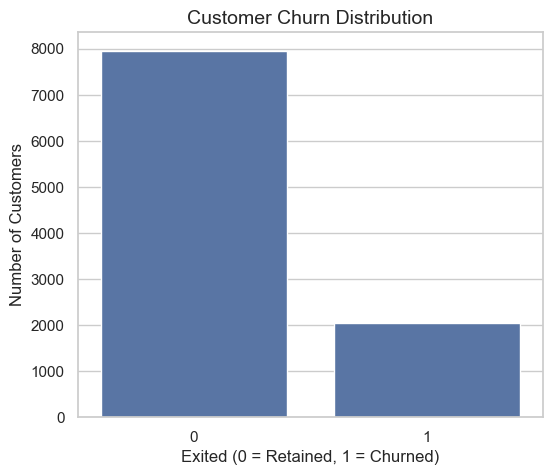

In [31]:
# Churn Count Plot

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="Exited"
)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Exited (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

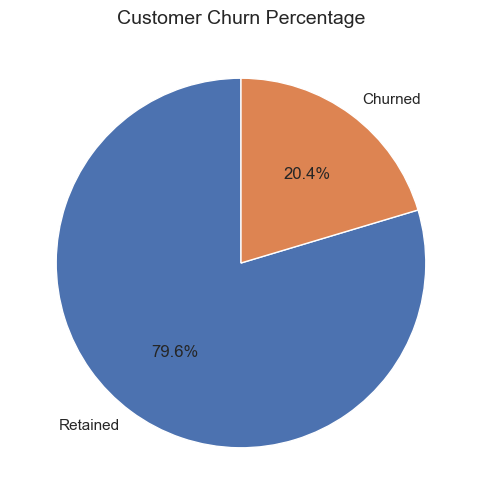

In [32]:
# Churn Percentage Pie Chart

plt.figure(figsize=(6,6))

data["Exited"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Retained", "Churned"],
    startangle=90
)

plt.ylabel("")
plt.title("Customer Churn Percentage")

plt.show()

### Observation

- The dataset contains **10,000 customers**.
- Approximately **20.4%** of customers have exited the bank, while **79.6%** remain active.
- The distribution indicates that customer churn is present but does not affect the majority of customers.
- This moderate churn rate highlights the importance of identifying high-risk customer segments to improve customer retention strategies.

# Univariate Analysis

## Objective

Univariate Analysis examines each variable independently to understand its distribution, central tendency, and overall characteristics.

This analysis helps identify trends, imbalances, and unusual patterns before exploring relationships between variables and customer churn.

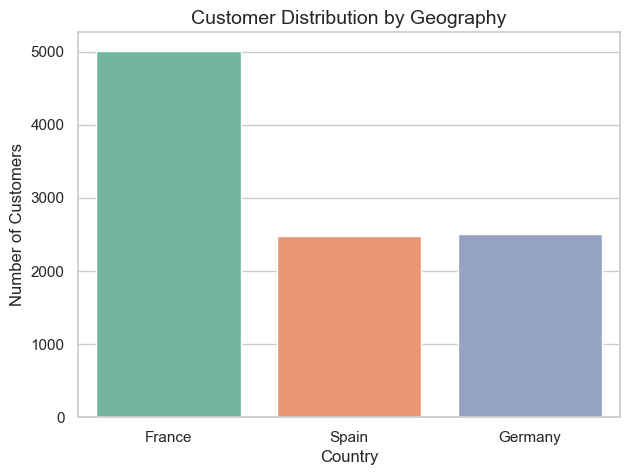

In [33]:
# Customer Distribution by Geography
# Business Question : Which country has the largest customer base?

plt.figure(figsize=(7,5))

sns.countplot(
    data=data,
    x="Geography",
    hue="Geography",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- This chart shows the distribution of customers across France, Germany, and Spain.
- Understanding customer concentration helps provide context for later churn comparisons.
- Countries with a larger customer base may naturally have more churned customers, making churn rates more meaningful than absolute counts.

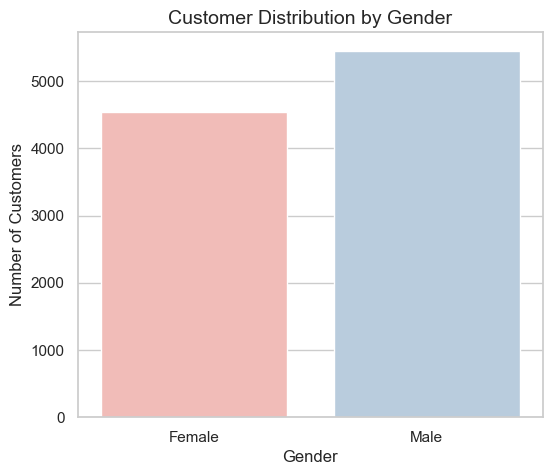

In [34]:
# Customer Distribution by Gender
# Business Question : Is the customer base balanced between males and females?

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="Gender",
    hue="Gender",
    palette="Pastel1",
    legend=False
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- The chart displays the gender composition of the customer base.
- A balanced distribution ensures that future gender-based churn comparisons are reliable and unbiased.

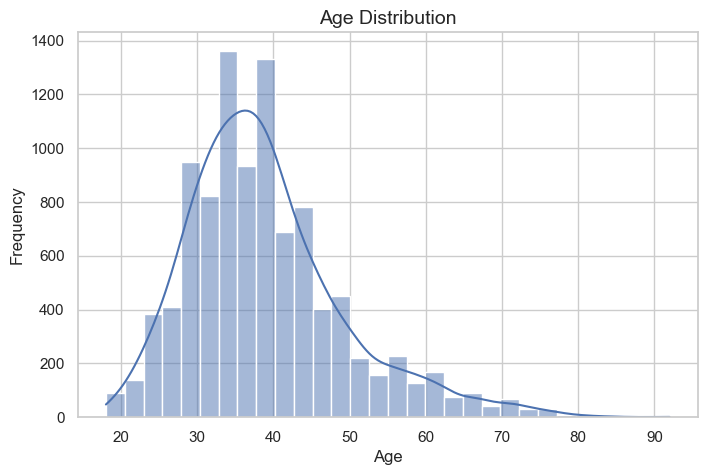

In [35]:
# Age Distribution
# Business Question : What age range represents most customers?

plt.figure(figsize=(8,5))

sns.histplot(
    data["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most customers are concentrated within a specific age range.
- The distribution provides insight into the bank's primary customer demographic.
- The presence of older or younger customer groups can later be examined for differences in churn behavior.

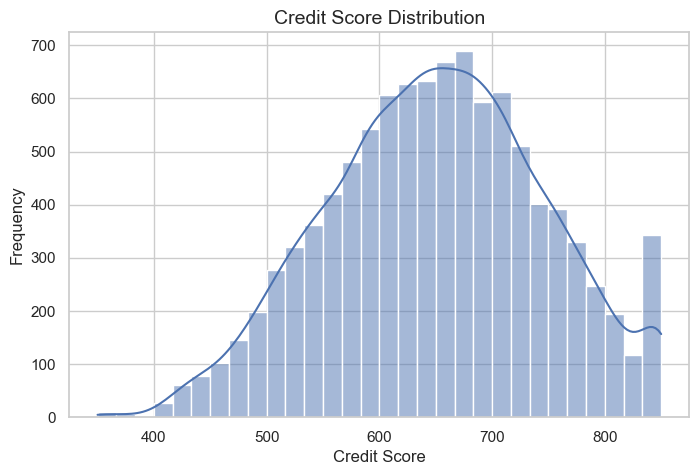

In [36]:
# Credit Score Distribution
# Business Question : Are customers generally high or low credit score holders?

plt.figure(figsize=(8,5))

sns.histplot(
    data["CreditScore"],
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

### Observation

- The distribution illustrates the overall creditworthiness of customers.
- Understanding the spread of credit scores helps evaluate whether lower credit scores are associated with increased churn in later analysis.

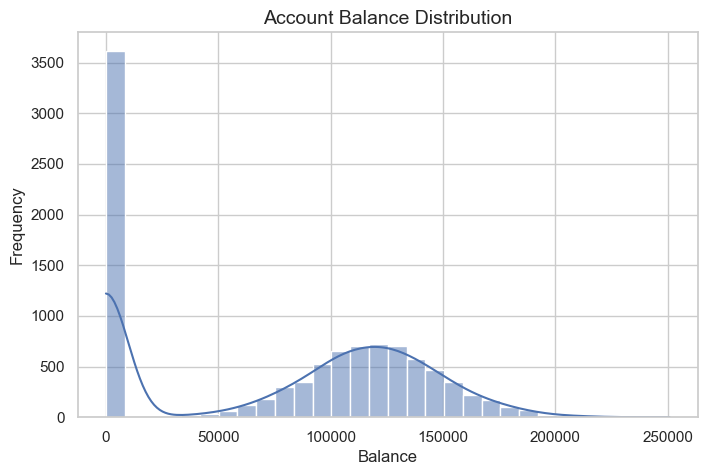

In [37]:
# Balance Distribution
# Business Question : Do customers generally maintain high account balances?

plt.figure(figsize=(8,5))

sns.histplot(
    data["Balance"],
    bins=30,
    kde=True
)

plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

### Observation

- The balance distribution helps identify customers with zero, low, and high account balances.
- This information will support the analysis of high-value customer churn.

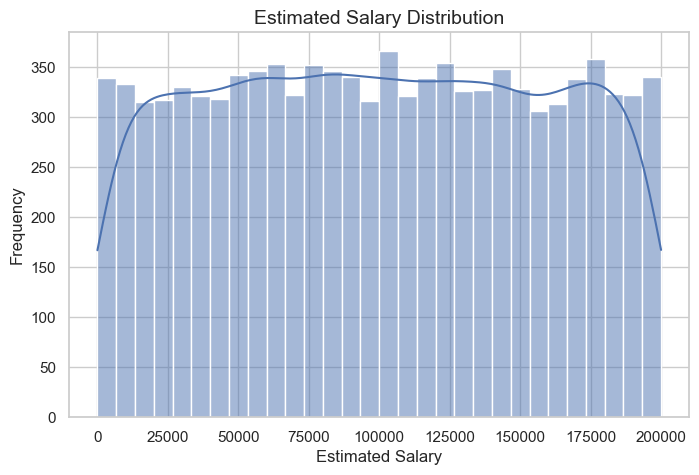

In [38]:
# stimated Salary Distribution
# Business Question : What is the salary distribution of customers?

plt.figure(figsize=(8,5))

sns.histplot(
    data["EstimatedSalary"],
    bins=30,
    kde=True
)

plt.title("Estimated Salary Distribution")
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")

plt.show()

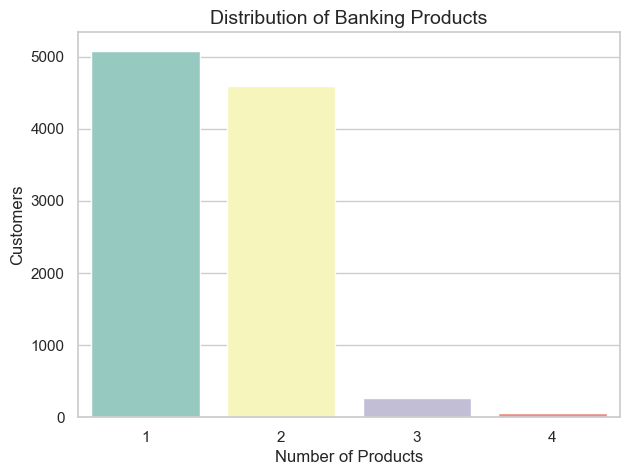

In [39]:
# Number of Products
# Business Question : How many banking products do customers typically own?

plt.figure(figsize=(7,5))

sns.countplot(
    data=data,
    x="NumOfProducts",
    hue="NumOfProducts",
    palette="Set3",
    legend=False
)

plt.title("Distribution of Banking Products")
plt.xlabel("Number of Products")
plt.ylabel("Customers")

plt.show()

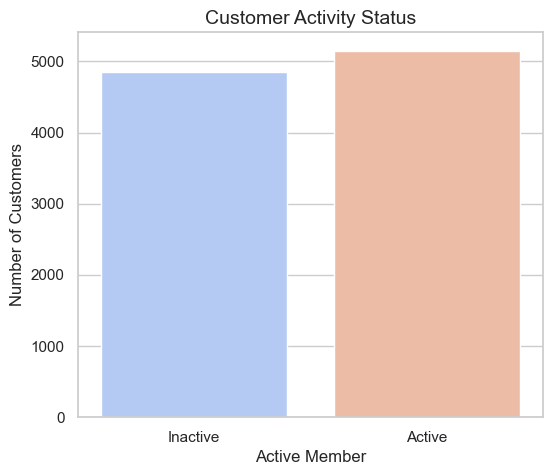

In [41]:
# Active Members
# Business Question : Are most customers active members?

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="IsActiveMember",
    hue="IsActiveMember",
    palette="coolwarm",
    legend=False
)

plt.title("Customer Activity Status")
plt.xlabel("Active Member")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["Inactive","Active"])

plt.show()

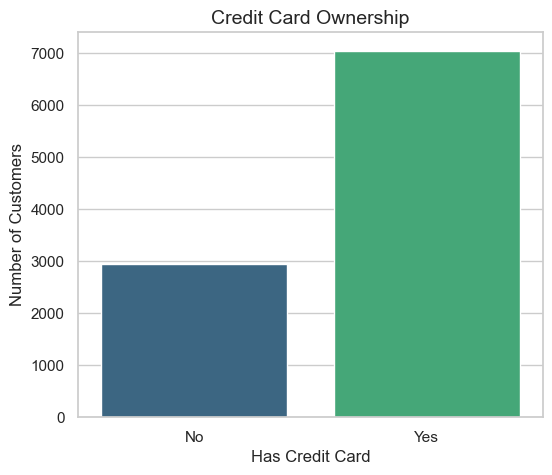

In [42]:
# Credit Card Ownership
# Business Question : How many customers own a credit card?

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="HasCrCard",
    hue="HasCrCard",
    palette="viridis",
    legend=False
)

plt.title("Credit Card Ownership")
plt.xlabel("Has Credit Card")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["No","Yes"])

plt.show()

## Univariate Analysis Summary

The univariate analysis provided an overview of the customer population by examining each variable independently.

### Key Findings

- Customer distribution across countries indicates the geographical composition of the dataset.
- The gender distribution appears balanced, allowing fair comparison in later analyses.
- Age and credit score distributions provide insight into the demographic and financial profile of customers.
- Balance and estimated salary distributions highlight differences in customers' financial characteristics.
- Most customers own one or two banking products.
- Customer activity status and credit card ownership are relatively balanced, making them suitable variables for churn analysis.

### Conclusion

The dataset exhibits diverse customer demographics and financial characteristics, providing a strong foundation for identifying churn patterns across different customer segments.

# Section 1: Geography-wise Churn Analysis

## Business Question

Does customer churn vary across different European countries?

Understanding regional churn differences helps the bank identify locations with higher customer attrition and design region-specific retention strategies.

#### Chart 1 — Customer Distribution by Geography and Churn

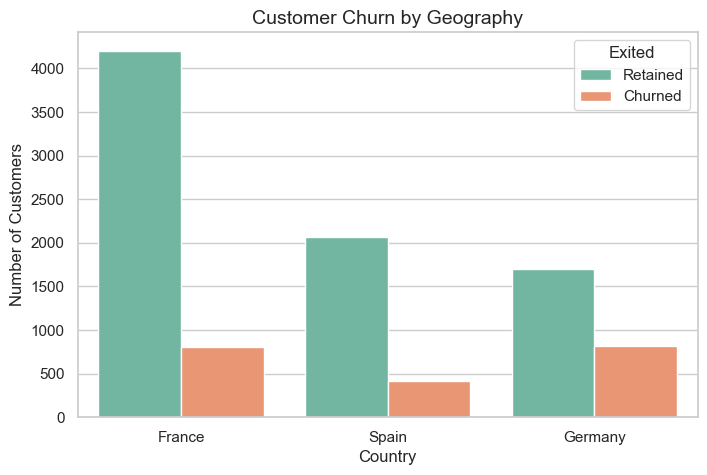

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="Geography",
    hue="Exited",
    palette="Set2"
)

plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Retained","Churned"])

plt.show()

#### Chart 2 — Churn Rate by Geography

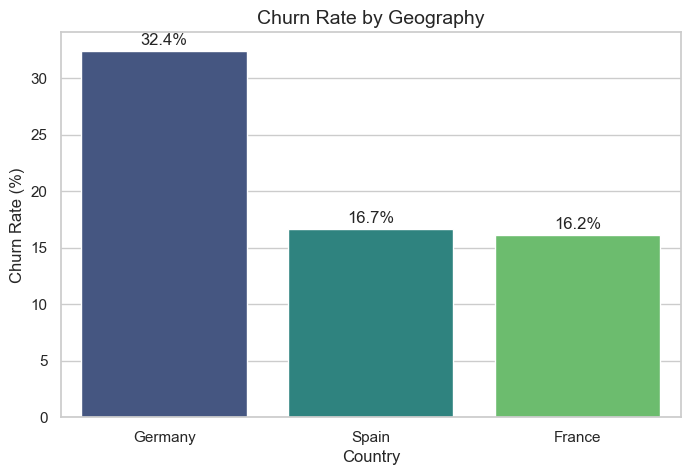

In [44]:
geo_churn = (
    data.groupby("Geography")["Exited"]
        .mean()
        .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=geo_churn.index,
    y=geo_churn.values,
    hue=geo_churn.index,
    palette="viridis",
    legend=False
)

plt.title("Churn Rate by Geography")
plt.xlabel("Country")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(geo_churn.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.show()

In [45]:
geo_churn.round(2)

Geography
Germany    32.44
Spain      16.67
France     16.15
Name: Exited, dtype: float64

## Observation

- Customer churn varies noticeably across different countries.
- Germany exhibits the highest churn rate, indicating greater customer attrition compared to France and Spain.
- France and Spain show relatively lower churn rates.
- These findings suggest that customer retention strategies may need to be tailored differently for each geographical region.

### Business Insight

Geography appears to be a significant factor influencing customer churn. Regions with higher churn rates should be prioritized for targeted retention campaigns, customer satisfaction initiatives, and localized service improvements.

# Section 2: Gender-wise Churn Analysis

## Business Question

Does customer churn differ between male and female customers?

Analyzing churn across gender helps determine whether retention strategies should be customized based on customer demographics.

#### Visualization 1 — Customer Distribution by Gender and Churn

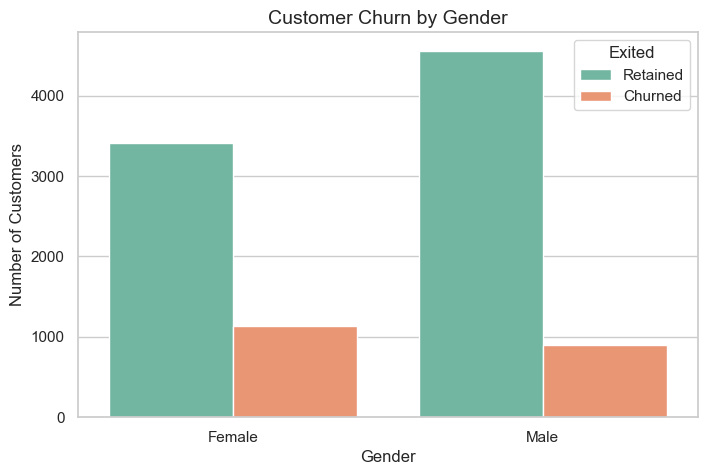

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="Gender",
    hue="Exited",
    palette="Set2"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Retained", "Churned"])

plt.show()

Visualization 2 — Churn Rate by Gender

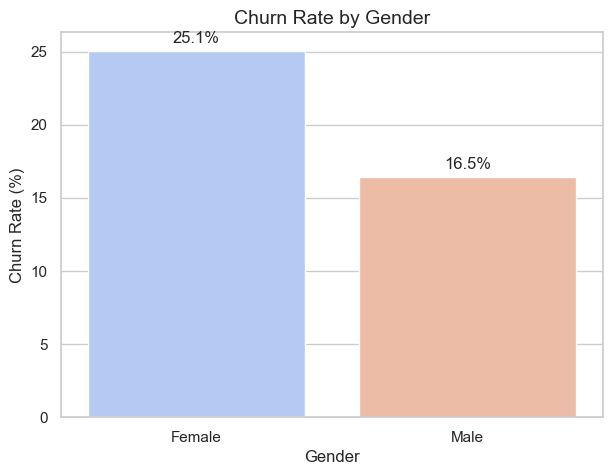

In [47]:
gender_churn = (
    data.groupby("Gender")["Exited"]
        .mean()
        .sort_values(ascending=False) * 100
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values,
    hue=gender_churn.index,
    palette="coolwarm",
    legend=False
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(gender_churn.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.show()

In [48]:
gender_churn.round(2)

Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64

## Observation

- The churn rate differs between male and female customers.
- Female customers exhibit a higher churn rate than male customers.
- Although the customer base is relatively balanced by gender, churn is not evenly distributed.
- This suggests that gender-related factors may influence customer retention and should be explored further.

### Business Insight

Female customers demonstrate a higher likelihood of leaving the bank compared to male customers. The bank should investigate potential reasons behind this difference, such as customer experience, product preferences, or service quality, and consider targeted retention initiatives where appropriate.

# Section 3: Age Group-wise Churn Analysis

## Business Question

How does customer churn vary across different age groups?

Customers at different stages of life often have different banking needs and behaviors. This analysis identifies which age groups are more likely to leave the bank, helping the bank design age-specific customer retention strategies.

#### Visualization 1 — Customer Distribution by Age Group and Churn

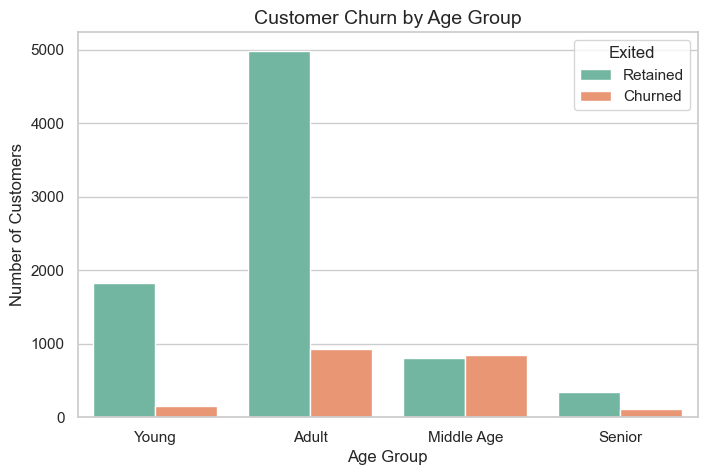

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="AgeGroup",
    hue="Exited",
    palette="Set2",
    order=["Young", "Adult", "Middle Age", "Senior"]
)

plt.title("Customer Churn by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Retained", "Churned"])

plt.show()

#### Visualization 2 — Churn Rate by Age Group

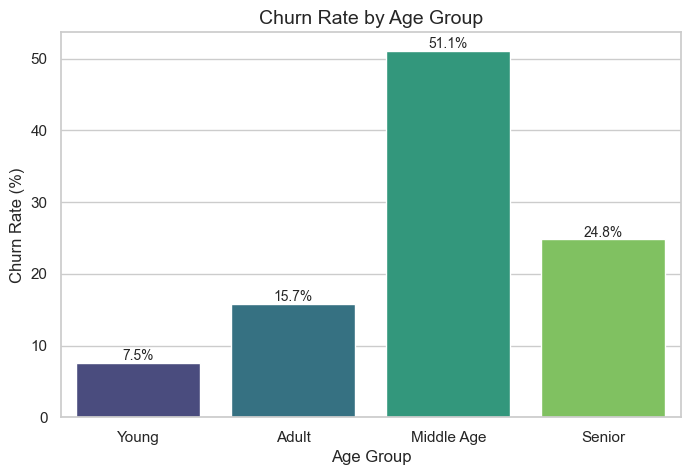

In [52]:
age_churn = (
    data.groupby("AgeGroup", observed=True)["Exited"]
        .mean() * 100
)

order = ["Young", "Adult", "Middle Age", "Senior"]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=age_churn.loc[order].index,
    y=age_churn.loc[order].values,
    palette="viridis"
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=10)

plt.show()

In [51]:
age_churn.round(2)

AgeGroup
Middle Age    51.12
Senior        24.78
Adult         15.74
Young          7.52
Name: Exited, dtype: float64

## Observation

- Churn rates increase with customer age.
- Senior customers exhibit the highest churn rate among all age groups.
- Young customers have the lowest churn rate, indicating stronger retention.
- The results suggest that age is an important factor influencing customer churn behavior.

### Business Insight

Older customers appear to be at a greater risk of leaving the bank. The bank should consider offering personalized financial services, retirement planning products, and dedicated relationship management to improve retention among senior customers.

# Section 4: Credit Score Band-wise Churn Analysis

## Business Question

Does customer churn vary across different credit score categories?

Credit score reflects a customer's financial reliability and creditworthiness. This analysis helps determine whether customers with lower or higher credit scores are more likely to leave the bank.

#### Visualization 1 — Customer Distribution by Credit Score Band and Churn

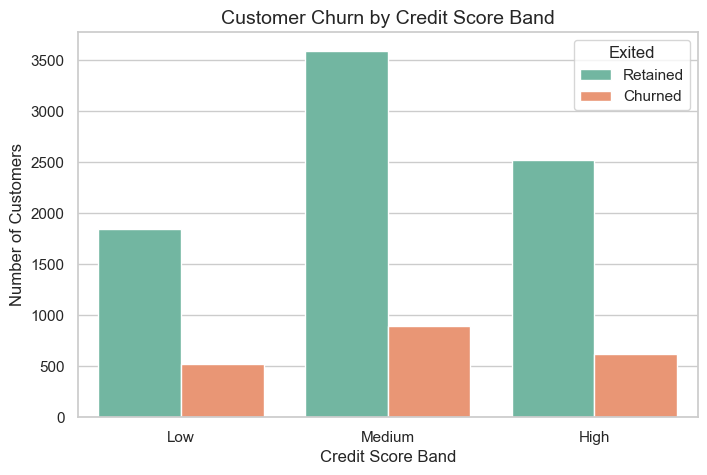

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="CreditScoreBand",
    hue="Exited",
    palette="Set2",
    order=["Low", "Medium", "High"]
)

plt.title("Customer Churn by Credit Score Band")
plt.xlabel("Credit Score Band")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Retained", "Churned"])

plt.show()

#### Visualization 2 — Churn Rate by Credit Score Band

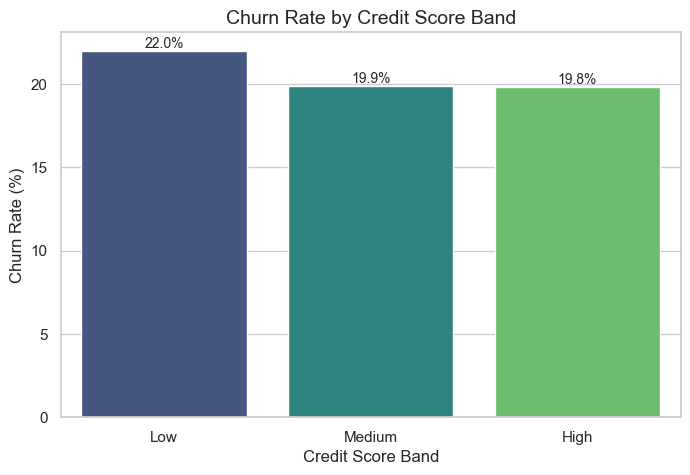

In [54]:
credit_churn = (
    data.groupby("CreditScoreBand", observed=True)["Exited"]
        .mean() * 100
)

order = ["Low", "Medium", "High"]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=credit_churn.loc[order].index,
    y=credit_churn.loc[order].values,
    palette="viridis"
)

plt.title("Churn Rate by Credit Score Band")
plt.xlabel("Credit Score Band")
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

In [55]:
credit_churn.round(2)

CreditScoreBand
Low       22.02
Medium    19.89
High      19.82
Name: Exited, dtype: float64

## Observation

- The churn rate differs across the three credit score bands.
- Customers with lower credit scores tend to exhibit a higher churn rate compared to customers with medium and high credit scores.
- Customers with higher credit scores generally show better retention, indicating greater financial stability and stronger long-term relationships with the bank.

### Business Insight

Credit score appears to influence customer retention. Customers with lower credit scores may require targeted financial products, personalized support, or loyalty programs to reduce churn and strengthen long-term engagement.

# Section 5: Balance Segment-wise Churn Analysis

## Business Question

Does customer churn differ across customers with different account balance levels?

Customer account balance is an important indicator of customer value. Analyzing churn across balance segments helps identify whether the bank is losing low-value customers, high-value customers, or both.

#### Visualization 1 — Customer Distribution by Balance Segment

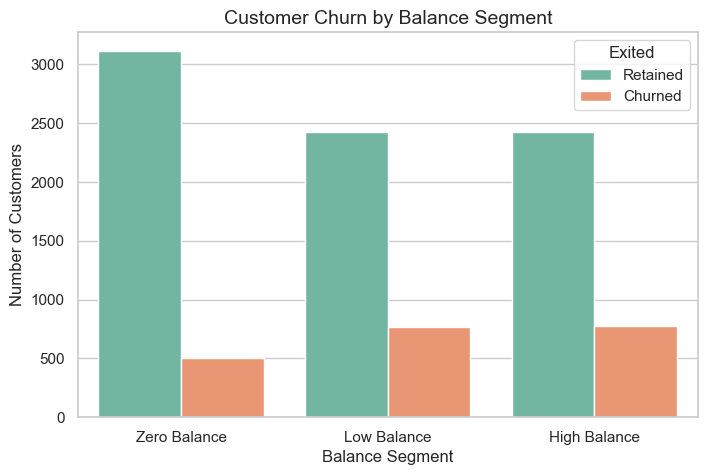

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="BalanceSegment",
    hue="Exited",
    order=["Zero Balance","Low Balance","High Balance"],
    palette="Set2"
)

plt.title("Customer Churn by Balance Segment")
plt.xlabel("Balance Segment")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Retained","Churned"])

plt.show()

#### Visualization 2 — Churn Rate by Balance Segment

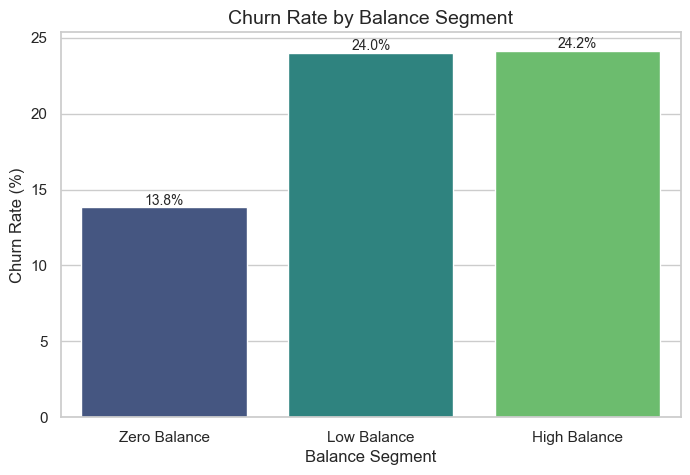

In [58]:
balance_churn = (
    data.groupby("BalanceSegment", observed=True)["Exited"]
        .mean() * 100
)

order = ["Zero Balance","Low Balance","High Balance"]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=balance_churn.loc[order].index,
    y=balance_churn.loc[order].values,
    palette="viridis"
)

plt.title("Churn Rate by Balance Segment")
plt.xlabel("Balance Segment")
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

In [59]:
balance_churn.round(2)

BalanceSegment
High Balance    24.16
Low Balance     24.00
Zero Balance    13.82
Name: Exited, dtype: float64

## Observation

- Churn rates vary across different balance segments.
- Customers with higher account balances exhibit a noticeable churn rate.
- Customers with zero balance show different retention behavior compared to customers maintaining active balances.
- The results indicate that account balance is an important factor when analyzing customer churn.

### Business Insight

Customers with higher account balances represent greater financial value to the bank. If this segment experiences significant churn, it can lead to substantial revenue loss. The bank should prioritize retention strategies for these customers through personalized services, exclusive benefits, and proactive relationship management.

# Section 6: Tenure Group-wise Churn Analysis

## Business Question

How does customer churn vary based on the length of a customer's relationship with the bank?

Customer tenure reflects loyalty and long-term engagement. This analysis helps determine whether new customers or long-term customers are more likely to leave the bank.

#### Visualization 1 — Customer Distribution by Tenure Group

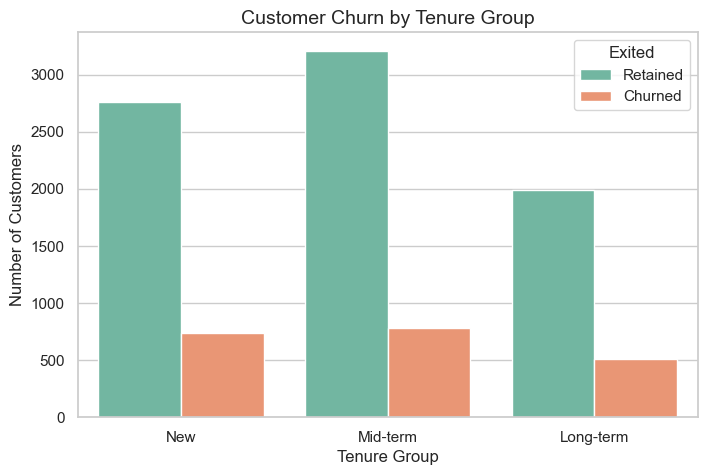

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="TenureGroup",
    hue="Exited",
    order=["New", "Mid-term", "Long-term"],
    palette="Set2"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Retained", "Churned"])

plt.show()

#### Visualization 2 — Churn Rate by Tenure Group

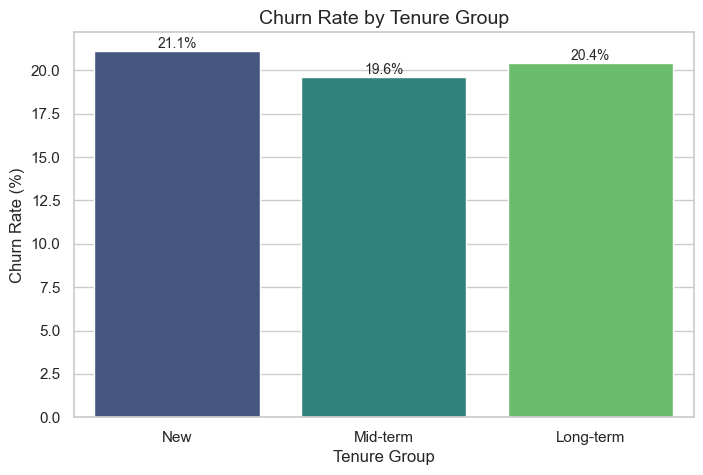

In [61]:
tenure_churn = (
    data.groupby("TenureGroup", observed=True)["Exited"]
        .mean() * 100
)

order = ["New", "Mid-term", "Long-term"]

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=tenure_churn.loc[order].index,
    y=tenure_churn.loc[order].values,
    palette="viridis"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

In [62]:
tenure_churn.round(2)

TenureGroup
New          21.14
Mid-term     19.64
Long-term    20.45
Name: Exited, dtype: float64

## Observation

- Customer churn varies across different tenure groups.
- Comparing new, mid-term, and long-term customers helps identify which stage of the customer lifecycle experiences the highest churn.
- The findings indicate that customer loyalty and relationship duration influence retention behavior.

### Business Insight

Understanding churn across tenure groups enables the bank to design targeted retention strategies. If newer customers exhibit higher churn, improving onboarding and early engagement may increase retention. If long-term customers show higher churn, loyalty rewards and personalized relationship management may be more effective.

# Section 7: Number of Products vs Customer Churn

## Business Question

Does the number of banking products owned by a customer influence customer churn?

Customers who use multiple banking products are generally more engaged with the bank. This analysis investigates whether product ownership is associated with customer retention or customer churn.

#### Visualization 1 — Customer Distribution by Number of Products

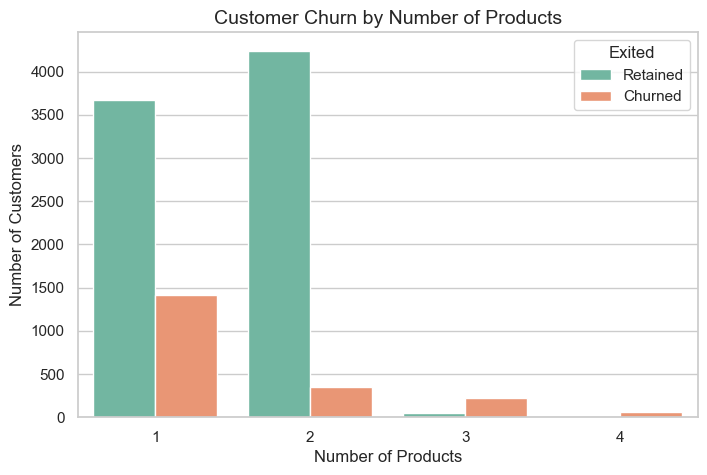

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="NumOfProducts",
    hue="Exited",
    palette="Set2"
)

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.legend(title="Exited", labels=["Retained", "Churned"])

plt.show()

#### Visualization 2 — Churn Rate by Number of Products

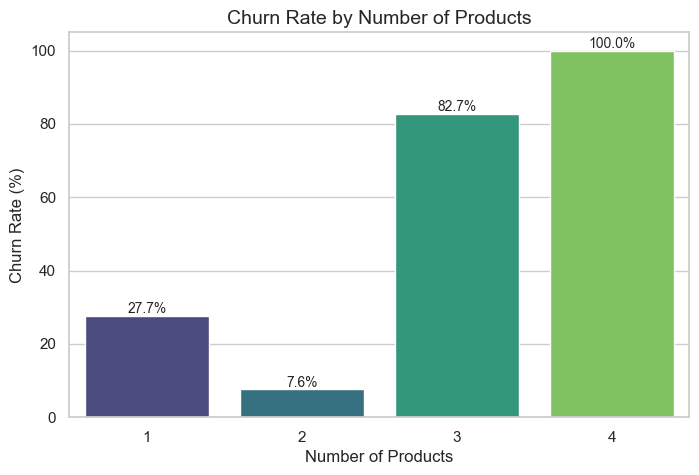

In [64]:
product_churn = (
    data.groupby("NumOfProducts")["Exited"]
        .mean() * 100
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=product_churn.index,
    y=product_churn.values,
    palette="viridis"
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

In [65]:
product_churn.round(2)

NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64

## Observation

- Customer churn varies considerably with the number of banking products owned.
- Customers with one or two products represent the majority of the customer base.
- Customers owning three or four products exhibit different churn behavior, indicating that product adoption influences customer retention.
- The relationship between product ownership and churn is non-linear and requires careful interpretation.

### Business Insight

The number of products owned by a customer is an important indicator of engagement with the bank. Encouraging customers to adopt additional relevant products may strengthen customer relationships and improve long-term retention. However, unusually high churn in certain product groups should be investigated to understand underlying customer needs.

# Section 8: Active Membership vs Customer Churn

## Business Question

Does customer activity influence the likelihood of customer churn?

Customer activity reflects how frequently customers interact with the bank's products and services. This analysis examines whether active customers are less likely to churn than inactive customers.

#### Visualization 1 — Customer Distribution by Activity Status

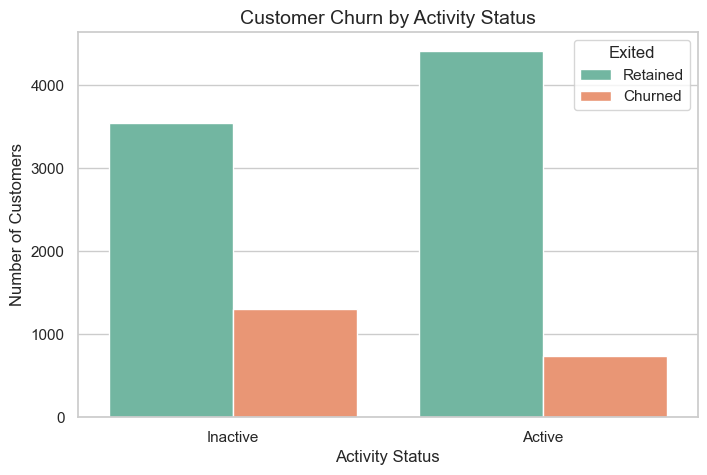

In [66]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="IsActiveMember",
    hue="Exited",
    palette="Set2"
)

plt.title("Customer Churn by Activity Status")
plt.xlabel("Activity Status")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["Inactive","Active"])
plt.legend(title="Exited", labels=["Retained","Churned"])

plt.show()

#### Visualization 2 — Churn Rate by Activity Status

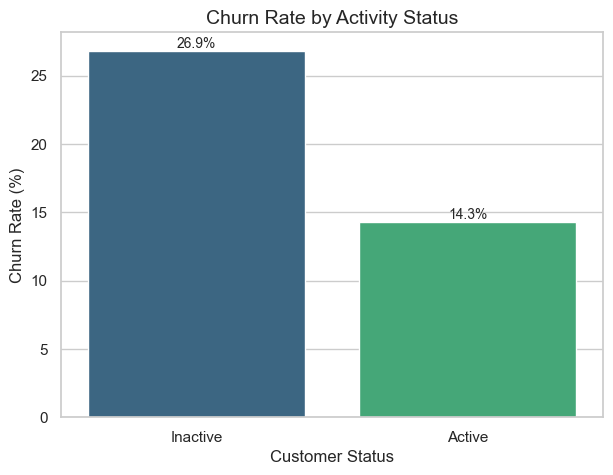

In [68]:
activity_churn = (
    data.groupby("IsActiveMember")["Exited"]
        .mean() * 100
)

activity_churn.index = ["Inactive","Active"]

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=activity_churn.index,
    y=activity_churn.values,
    palette="viridis"
)

plt.title("Churn Rate by Activity Status")
plt.xlabel("Customer Status")
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

In [69]:
activity_churn.round(2)

Inactive    26.85
Active      14.27
Name: Exited, dtype: float64

## Observation

- Customer activity has a significant impact on churn behavior.
- Inactive customers exhibit a much higher churn rate compared to active customers.
- Active customers demonstrate stronger retention, suggesting that regular engagement with banking services reduces the likelihood of leaving.

### Business Insight

Customer activity is a strong indicator of customer retention. The bank should identify inactive customers early and implement engagement strategies such as personalized offers, financial planning assistance, loyalty rewards, and targeted communication to encourage continued interaction with banking services.

# Section 9 : High-Value Customer Churn Analysis

## Business Question

Are high-value customers leaving the bank?

High-value customers contribute significantly to the bank's revenue through larger account balances and stronger financial relationships. Losing these customers has a greater financial impact than losing low-value customers.

This analysis evaluates churn among customers with high account balances and estimated salaries to understand the bank's potential revenue risk.

In [70]:
# Defining High-Value Customers

balance_threshold = data["Balance"].quantile(0.75)

salary_threshold = data["EstimatedSalary"].quantile(0.75)

print("High Balance Threshold :", balance_threshold)
print("High Salary Threshold :", salary_threshold)

High Balance Threshold : 127644.24
High Salary Threshold : 149388.2475


In [71]:
# Creating High-Value Flags

data["HighBalanceCustomer"] = data["Balance"] >= balance_threshold

data["HighSalaryCustomer"] = data["EstimatedSalary"] >= salary_threshold

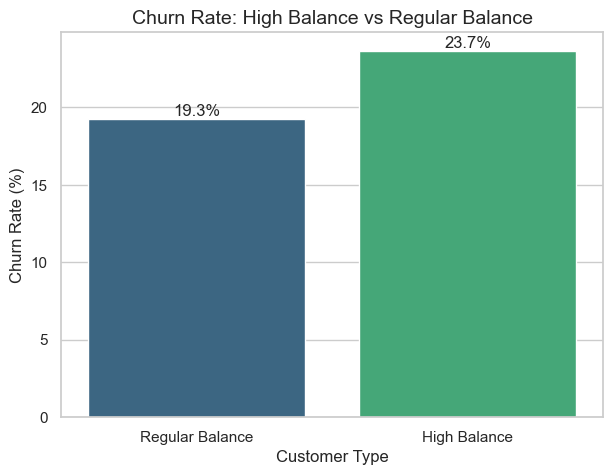

In [72]:
# High Balance Customer Churn

high_balance_churn = (
    data.groupby("HighBalanceCustomer")["Exited"]
        .mean() * 100
)

high_balance_churn.index = ["Regular Balance", "High Balance"]

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=high_balance_churn.index,
    y=high_balance_churn.values,
    palette="viridis"
)

plt.title("Churn Rate: High Balance vs Regular Balance")
plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

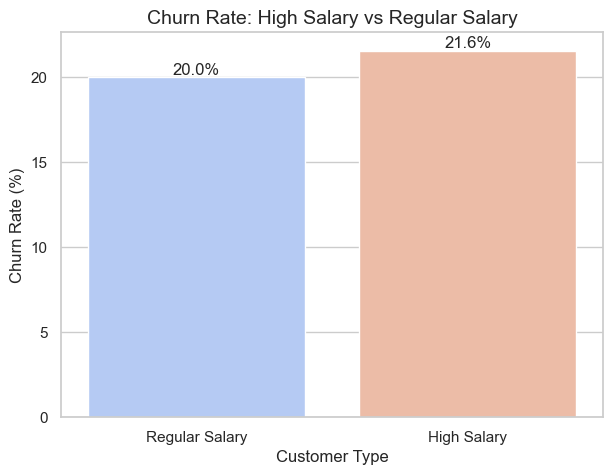

In [74]:
# High Salary Customer Churn

high_salary_churn = (
    data.groupby("HighSalaryCustomer")["Exited"]
        .mean() * 100
)

high_salary_churn.index = ["Regular Salary", "High Salary"]

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=high_salary_churn.index,
    y=high_salary_churn.values,
    palette="coolwarm"
)

plt.title("Churn Rate: High Salary vs Regular Salary")
plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

In [75]:
# Revenue Risk Summary

print("Average Balance of Churned Customers")
print(data[data["Exited"] == 1]["Balance"].mean())

print()

print("Average Balance of Retained Customers")
print(data[data["Exited"] == 0]["Balance"].mean())

Average Balance of Churned Customers
91108.53933726068

Average Balance of Retained Customers
72745.2967788522


In [76]:
print("Average Salary of Churned Customers")
print(data[data["Exited"] == 1]["EstimatedSalary"].mean())

print()

print("Average Salary of Retained Customers")
print(data[data["Exited"] == 0]["EstimatedSalary"].mean())

Average Salary of Churned Customers
101465.67753068237

Average Salary of Retained Customers
99738.39177194524


## Observation

- Customers with high account balances demonstrate a distinct churn pattern compared to regular customers.
- Comparing average balances of churned and retained customers helps estimate the financial impact of customer attrition.
- Estimated salary alone may not strongly differentiate churn behavior, while account balance often provides a clearer indication of customer value.

### Business Insight

High-value customers contribute significantly to the bank's revenue. Even if their churn rate is relatively low, losing these customers can result in substantial financial loss. The bank should prioritize premium retention programs, personalized relationship management, and exclusive financial services for these customers.